<a href="https://colab.research.google.com/github/elisecolin/Tutorials_Notebooks/blob/main/Impulsion_Compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Radar Pulse Compression Demo with Audio
# ------------------------------------------------------------
# This notebook demonstrates:
#   1. A pure sinusoidal pulse
#   2. A linear chirp
#   3. Their matched-filter responses
#   4. Audio rendering
#
# ============================================================



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import chirp

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

fs = 44100

Tpulse = 0.25
Ttotal = 1.0

f0 = 600
f_start = 300
f_end = 2000

# ------------------------------------------------------------
# TIME AXES
# ------------------------------------------------------------

t_total = np.linspace(0, Ttotal, int(fs*Ttotal), endpoint=False)

pulse_samples = int(fs * Tpulse)

t_pulse = np.linspace(0, Tpulse, pulse_samples, endpoint=False)

# ------------------------------------------------------------
# CREATE EMPTY SIGNALS
# ------------------------------------------------------------

sinusoid = np.zeros_like(t_total)

chirp_signal = np.zeros_like(t_total)

# ------------------------------------------------------------
# INSERT PULSE IN THE MIDDLE
# ------------------------------------------------------------

start = len(t_total)//2 - pulse_samples//2
end = start + pulse_samples

# Pure tone pulse
sinusoid[start:end] = np.cos(2*np.pi*f0*t_pulse)

# Chirp pulse
chirp_signal[start:end] = chirp(
    t_pulse,
    f0=f_start,
    f1=f_end,
    t1=Tpulse,
    method='linear'
)

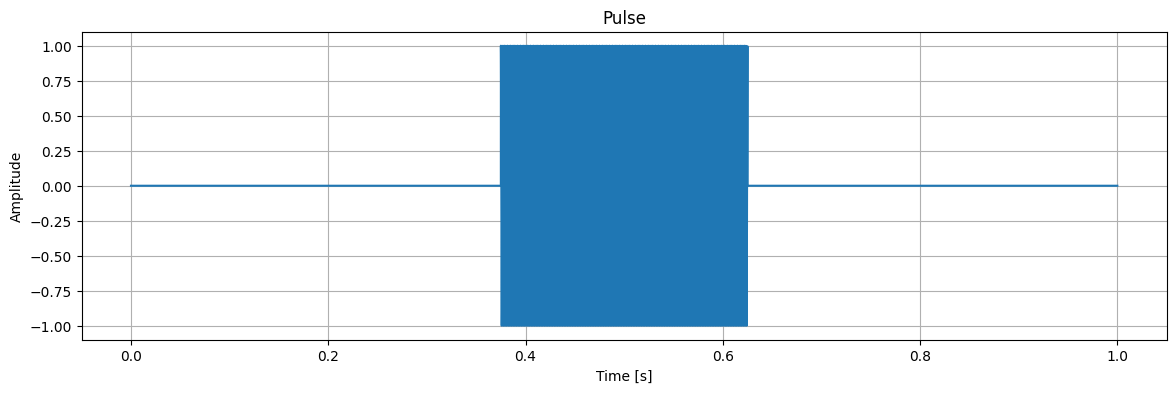

In [3]:
plt.figure(figsize=(14,4))

plt.plot(t_total, sinusoid)

plt.title("Pulse")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.grid()

plt.show()

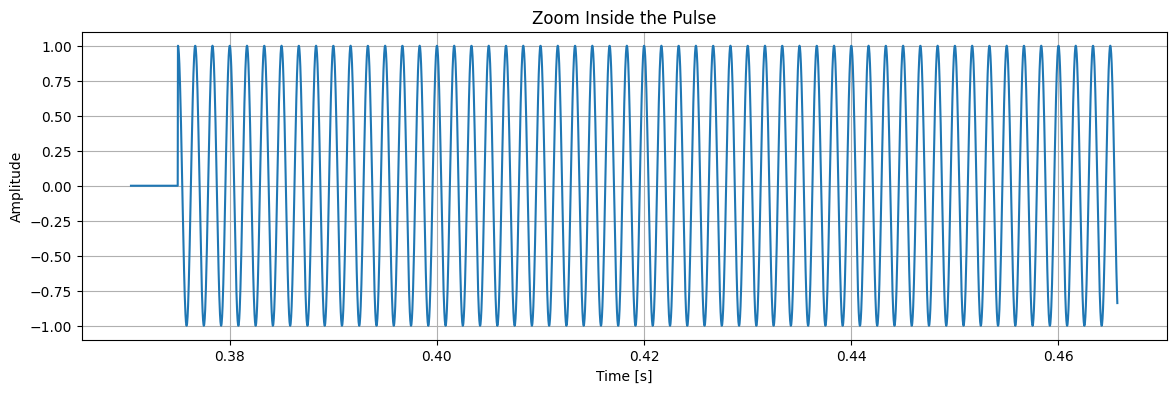

In [4]:
zoom_start = start - 200
zoom_end = start + 4000

plt.figure(figsize=(14,4))

plt.plot(
    t_total[zoom_start:zoom_end],
    sinusoid[zoom_start:zoom_end]
)

plt.title("Zoom Inside the Pulse")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.grid()

plt.show()

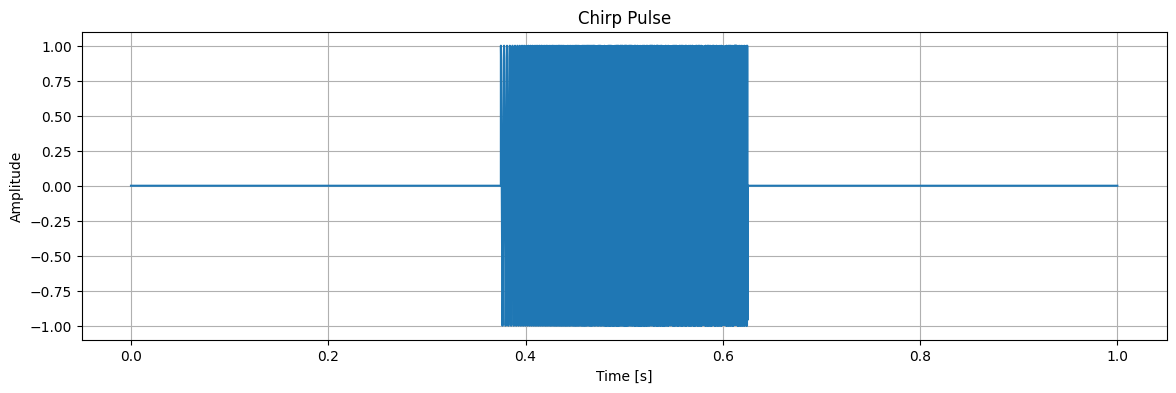

In [5]:
plt.figure(figsize=(14,4))

plt.plot(t_total, chirp_signal)

plt.title("Chirp Pulse")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.grid()

plt.show()

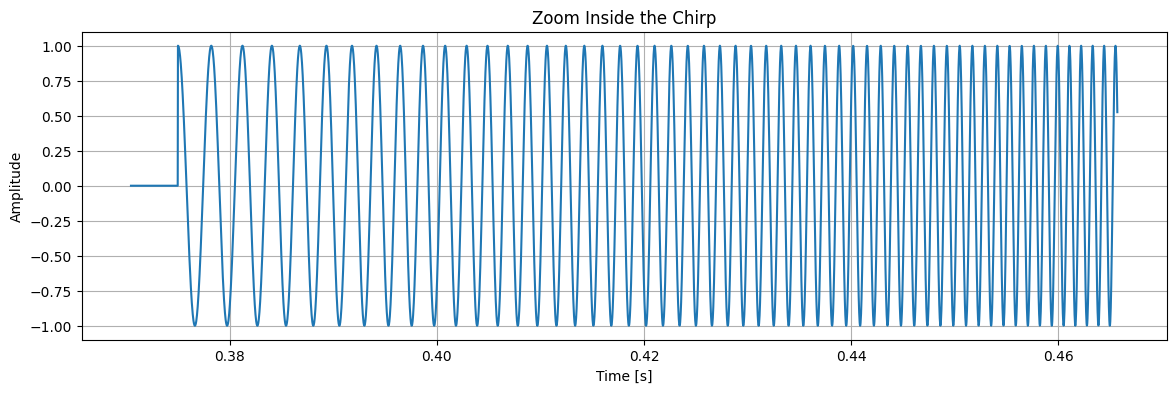

In [6]:
zoom_start = start - 200
zoom_end = start + 4000

plt.figure(figsize=(14,4))

plt.plot(
    t_total[zoom_start:zoom_end],
    chirp_signal[zoom_start:zoom_end]
)

plt.title("Zoom Inside the Chirp")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.grid()

plt.show()

In [7]:
# ------------------------------------------------------------
# LINEAR CHIRP
# ------------------------------------------------------------
# Normalize
chirp_audio = chirp_signal / np.max(np.abs(chirp_signal))
from scipy.io.wavfile import write

# Save audio
write("chirp.wav", fs, (chirp_audio * 32767).astype(np.int16))

print("Chirp generated.")



Chirp generated.


In [8]:
# ------------------------------------------------------------
# MATCHED FILTERING
# ------------------------------------------------------------
# Matched filter = convolution with time-reversed replica
from scipy.signal import chirp, fftconvolve

matched_sinusoid = fftconvolve(
    sinusoid,
    sinusoid[::-1],
    mode='same'
)

matched_chirp = fftconvolve(
    chirp_signal,
    chirp_signal[::-1],
    mode='same'
)

# Normalize audio
matched_sinusoid_audio = matched_sinusoid / np.max(np.abs(matched_sinusoid))
matched_chirp_audio = matched_chirp / np.max(np.abs(matched_chirp))

# Save audio
write(
    "matched_sinusoid.wav",
    fs,
    (matched_sinusoid_audio * 32767).astype(np.int16)
)

write(
    "matched_chirp.wav",
    fs,
    (matched_chirp_audio * 32767).astype(np.int16)
)

print("Matched filtering completed.")


Matched filtering completed.


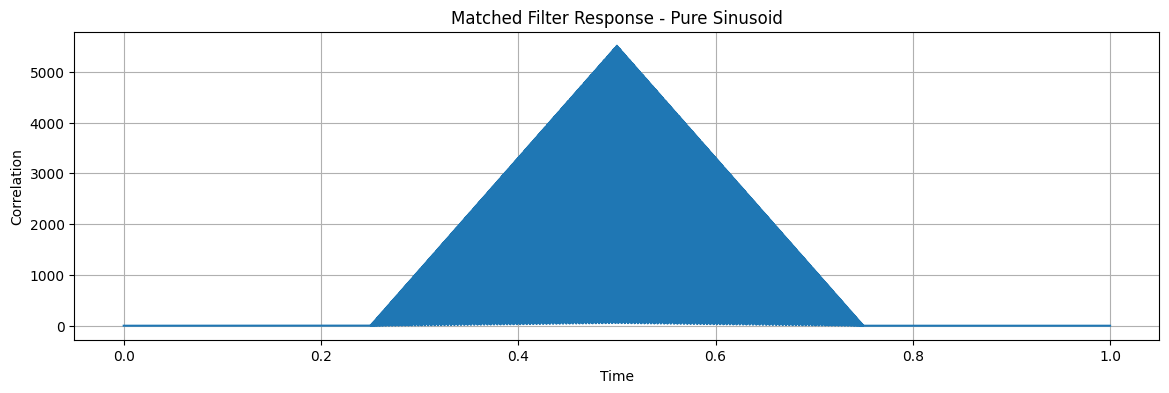

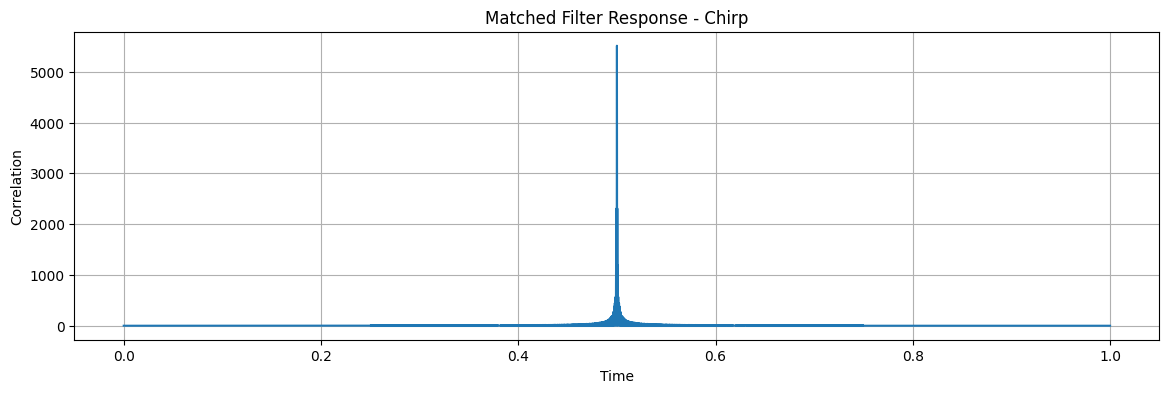

In [9]:
# ------------------------------------------------------------
# MATCHED FILTER OUTPUTS
# ------------------------------------------------------------

lags = np.arange(len(matched_sinusoid)) / fs

plt.figure(figsize=(14,4))
plt.plot(lags, np.abs(matched_sinusoid))
plt.title("Matched Filter Response - Pure Sinusoid")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.grid()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(lags, np.abs(matched_chirp))
plt.title("Matched Filter Response - Chirp")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.grid()
plt.show()



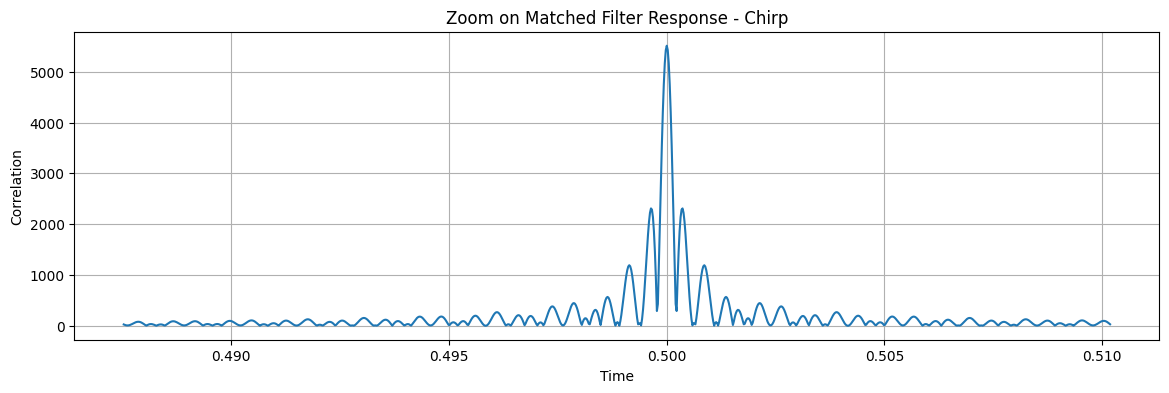

In [10]:

plt.figure(figsize=(14,4))
plt.plot(lags[21500:22500], np.abs(matched_chirp[21500:22500]))
plt.title("Zoom on Matched Filter Response - Chirp")
plt.xlabel("Time")
plt.ylabel("Correlation")
#plt.xlim([-0.45, 0.55])
plt.grid()
plt.show()

In [11]:

# ------------------------------------------------------------
# AUDIO PLAYBACK
# ------------------------------------------------------------
from IPython.display import Audio, display

print("\n--- PURE SINUSOID ---")
display(Audio(sinusoid, rate=fs))

print("\n--- CHIRP ---")
display(Audio(chirp_audio, rate=fs))

print("\n--- MATCHED FILTER OF PURE SINUSOID ---")
display(Audio(matched_sinusoid_audio, rate=fs))

print("\n--- MATCHED FILTER OF CHIRP ---")
display(Audio(matched_chirp_audio, rate=fs))




--- PURE SINUSOID ---



--- CHIRP ---



--- MATCHED FILTER OF PURE SINUSOID ---



--- MATCHED FILTER OF CHIRP ---


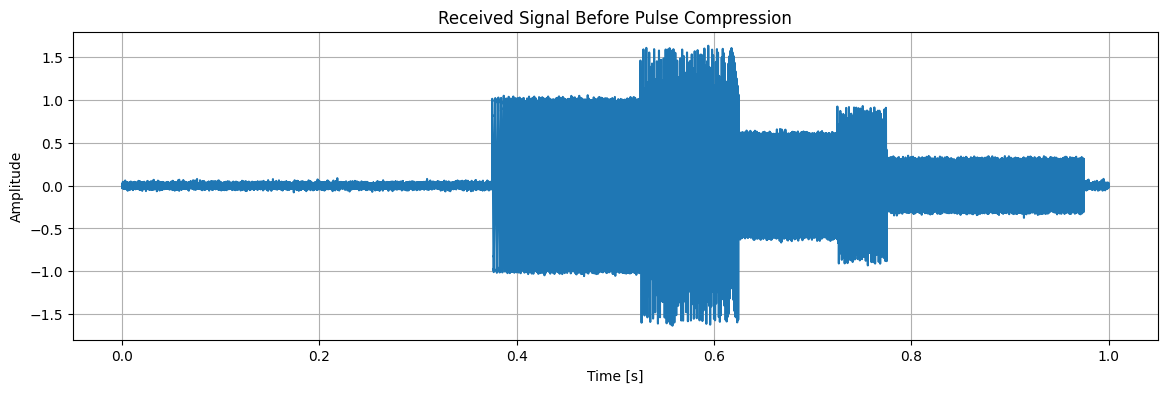

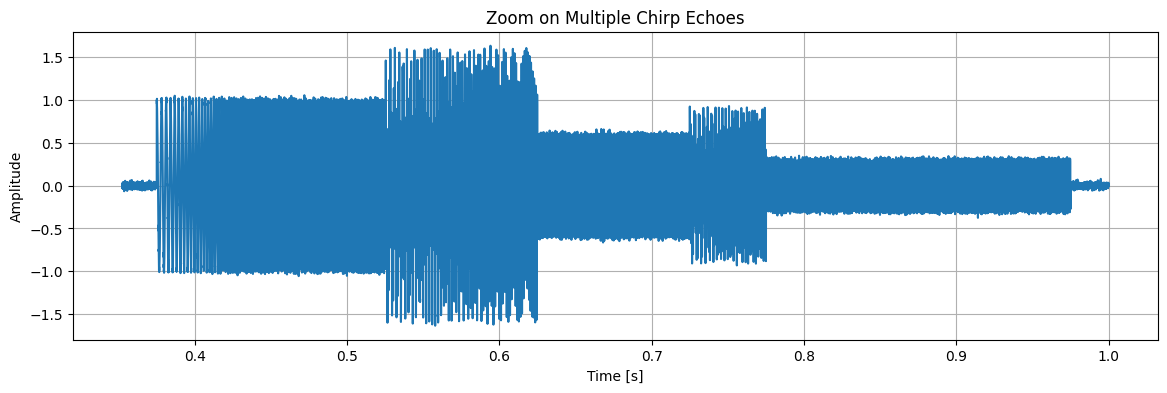


--- RECEIVED MULTI-ECHO SIGNAL ---


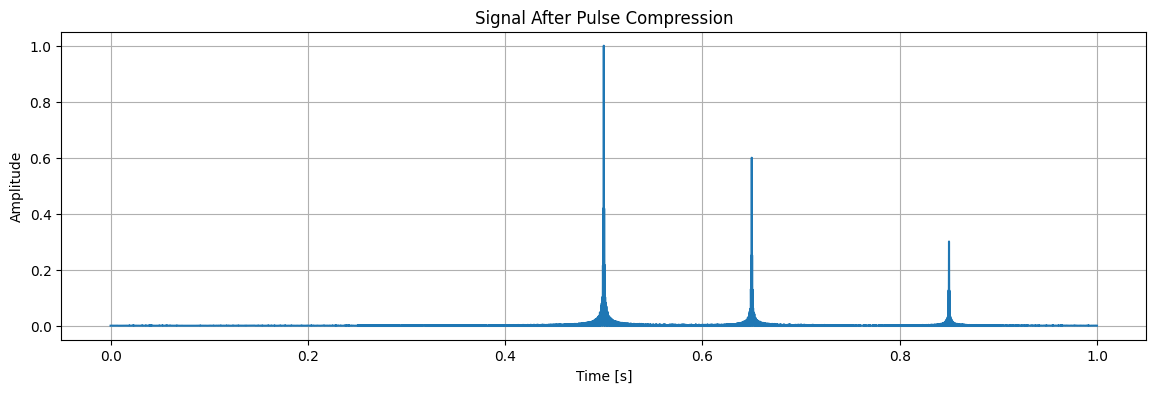


--- AFTER MATCHED FILTERING ---


In [12]:
# ------------------------------------------------------------
# SIMULATED ECHOES
# ------------------------------------------------------------

# Create delayed copies to simulate targets

delay1 = int(0.15 * fs)
delay2 = int(0.35 * fs)

echo_signal = np.zeros_like(chirp_signal)

# Direct path
echo_signal += chirp_signal

# Echoes
echo_signal += 0.6 * np.roll(chirp_signal, delay1)
echo_signal += 0.3 * np.roll(chirp_signal, delay2)

# Add noise
echo_signal += 0.02 * np.random.randn(len(echo_signal))

# ------------------------------------------------------------
# PLOT RECEIVED SIGNAL BEFORE COMPRESSION
# ------------------------------------------------------------

plt.figure(figsize=(14,4))

plt.plot(t_total, echo_signal)

plt.title("Received Signal Before Pulse Compression")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.grid()

plt.show()

# ------------------------------------------------------------
# ZOOM INSIDE RECEIVED SIGNAL
# ------------------------------------------------------------

plt.figure(figsize=(14,4))

plt.plot(
    t_total[start-1000:end+delay2+3000],
    echo_signal[start-1000:end+delay2+3000]
)

plt.title("Zoom on Multiple Chirp Echoes")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.grid()

plt.show()

# ------------------------------------------------------------
# AUDIO BEFORE COMPRESSION
# ------------------------------------------------------------

echo_audio = echo_signal / np.max(np.abs(echo_signal))

print("\n--- RECEIVED MULTI-ECHO SIGNAL ---")

display(Audio(echo_audio, rate=fs))

# ------------------------------------------------------------
# MATCHED FILTERING
# ------------------------------------------------------------

echo_compressed = fftconvolve(
    echo_signal,
    chirp_signal[::-1],
    mode='same'
)

# Normalize
echo_compressed_norm = echo_compressed / np.max(np.abs(echo_compressed))

# ------------------------------------------------------------
# PLOT AFTER COMPRESSION
# ------------------------------------------------------------

plt.figure(figsize=(14,4))

plt.plot(
    t_total,
    np.abs(echo_compressed_norm)
)

plt.title("Signal After Pulse Compression")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.grid()

plt.show()


# ------------------------------------------------------------
# AUDIO AFTER MATCHED FILTERING
# ------------------------------------------------------------
# Use absolute value to hear the compressed peaks better

compressed_audio = np.abs(echo_compressed_norm)

compressed_audio /= np.max(compressed_audio)

print("\n--- AFTER MATCHED FILTERING ---")

display(Audio(compressed_audio, rate=fs))